# Ridge and Lasso regularization: richer models without overfitting

<a target="_blank" href="https://colab.research.google.com/github/changyaochen/MECE4520/blob/master/site/evaluation/02-ridge-regularization.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab"/></a>

Adding measured operating features can give a regression model access to more useful information. It also gives the model more ways to fit details that may not repeat in future operation. In this notebook, we predict nitrogen-oxides concentration (**NOX**) from a fixed set of gas-turbine measurements and use **ridge** and **Lasso regularization** to control that tradeoff.

The question is: can we keep a richer set of plausible features while limiting overfitting?

## 1. A limited calibration campaign

Each row is one gas-turbine operating observation. We use nine measured operating quantities as features: ambient conditions (`AT`, `AP`, `AH`), pressure and temperature measurements (`AFDP`, `GTEP`, `TIT`, `TAT`, `CDP`), and energy yield (`TEY`). The response is measured NOX concentration. We deliberately do **not** use CO: our goal is to predict NOX from operating measurements, rather than from another simultaneously measured emission.

To make the generalization problem visible, imagine a limited calibration campaign with 75 real observations. We fit models on 65% of them and reserve the other 35% as a **validation set**. This intentionally small example helps reveal overfitting; it does not claim that 75 observations are generally sufficient for turbine modeling.

We will use this validation set to choose regularization strengths. That makes it a validation set, not an untouched final test set.

In [1]:
from pathlib import Path
from urllib.request import urlretrieve

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler

sns.set_theme(context="notebook", palette="deep")
deep_palette = sns.color_palette("deep")
training_color, validation_color, ridge_color = (
    deep_palette[0],
    deep_palette[1],
    deep_palette[2],
)

DATA_URL = (
    "https://raw.githubusercontent.com/changyaochen/MECE4520/master/"
    "site/data/gas-turbine-course.csv"
)
data_candidates = [
    Path("../data/gas-turbine-course.csv"),
    Path("site/data/gas-turbine-course.csv"),
    Path("gas-turbine-course.csv"),
]
data_path = next((path for path in data_candidates if path.exists()), data_candidates[-1])

# In Google Colab, download the small course dataset when it is not already present.
if not data_path.exists():
    urlretrieve(DATA_URL, data_path)

FEATURES = ["AT", "AP", "AH", "AFDP", "GTEP", "TIT", "TAT", "TEY", "CDP"]
TARGET = "NOX"

data = pd.read_csv(data_path)
calibration_data = data[FEATURES + [TARGET]].dropna().sample(n=75, random_state=48)
training_data, validation_data = train_test_split(
    calibration_data,
    test_size=0.35,
    random_state=479,
)

split_summary = pd.DataFrame(
    {"observations": [len(training_data), len(validation_data)]},
    index=["Training set", "Validation set"],
)
split_summary


,observations
Training set,48
Validation set,27


## 2. Start with all measured features

Our baseline is ordinary least squares using every feature in `FEATURES`. Relative to the earlier AT-only regression, this is a richer candidate feature set, but it uses no engineered polynomial or interaction features.

We place `StandardScaler` inside every model pipeline. The scaler learns each feature's mean and standard deviation **from the training data only**, then applies those values to validation observations. Standardization does not change ordinary least-squares predictions. It matters for ridge and Lasso because their penalties compare coefficient sizes across features measured in very different units.

In [2]:
def make_ridge_model(lambda_: float | None) -> Pipeline:
    """Create a standardized ordinary least-squares or ridge-regression pipeline.

    Args:
        lambda_: Ridge penalty strength. Use ``None`` for ordinary least squares.

    Returns:
        A pipeline that standardizes features using training statistics before fitting.
    """
    estimator = LinearRegression() if lambda_ is None else Ridge(alpha=lambda_)
    return make_pipeline(StandardScaler(), estimator)


def root_mean_squared_error(y_true: pd.Series, prediction: np.ndarray) -> float:
    """Compute RMSE in the physical units of the NOX response.

    Args:
        y_true: Observed NOX concentrations.
        prediction: Model-predicted NOX concentrations.

    Returns:
        Root mean squared error in mg/m³.
    """
    return mean_squared_error(y_true, prediction) ** 0.5


ols_model = make_ridge_model(lambda_=None)
ols_model.fit(training_data[FEATURES], training_data[TARGET])

ols_summary = pd.DataFrame(
    {
        "training RMSE (mg/m³)": [
            root_mean_squared_error(
                training_data[TARGET], ols_model.predict(training_data[FEATURES])
            )
        ],
        "validation RMSE (mg/m³)": [
            root_mean_squared_error(
                validation_data[TARGET], ols_model.predict(validation_data[FEATURES])
            )
        ],
    },
    index=["Ordinary least squares"],
)
ols_summary.round(3)


,training RMSE (mg/m³),validation RMSE (mg/m³)
Ordinary least squares,5.846,14.637


## 3. Add a ridge penalty

For ridge regression, we minimize the usual sum of squared residuals plus a penalty on the feature coefficients:

$$
J_{\lambda}(\boldsymbol{\beta})
=
\sum_{i=1}^{n_{\mathrm{train}}}
\left(y_i - \beta_0 - \mathbf{x}_i^T\boldsymbol{\beta}\right)^2
+
\lambda\sum_{j=1}^{d}\beta_j^2.
$$

The intercept $\beta_0$ is not penalized. When $\lambda=0$, the penalty disappears and we recover ordinary least squares. As $\lambda$ grows, large feature coefficients become more expensive, so the fitted model shrinks them toward zero.

This is the same loss-plus-penalty pattern used throughout machine learning. In this notebook, we call its strength $\lambda$; scikit-learn calls the matching `Ridge` argument `alpha`. Its loss term is a sum rather than a mean, so the numerical scale of $\lambda$ depends on that convention and on the data. We choose it using validation performance.

In [3]:
def fit_ridge_and_score(lambda_: float | None) -> tuple[Pipeline, dict[str, float | str]]:
    """Fit one model and evaluate it on the fixed training and validation split.

    Args:
        lambda_: Ridge penalty strength, or ``None`` for ordinary least squares.

    Returns:
        The fitted pipeline and a row of training and validation metrics.
    """
    model = make_ridge_model(lambda_)
    model.fit(training_data[FEATURES], training_data[TARGET])

    row = {
        "model": "OLS" if lambda_ is None else f"Ridge (λ = {lambda_:g})",
        "lambda": 0.0 if lambda_ is None else lambda_,
        "training RMSE": root_mean_squared_error(
            training_data[TARGET], model.predict(training_data[FEATURES])
        ),
        "validation RMSE": root_mean_squared_error(
            validation_data[TARGET], model.predict(validation_data[FEATURES])
        ),
    }
    return model, row


candidate_lambdas = np.logspace(-3, 6, 19)
fitted_models: dict[str, Pipeline] = {}

ols_model, ols_row = fit_ridge_and_score(lambda_=None)
fitted_models[ols_row["model"]] = ols_model
rows = [ols_row]

for lambda_ in candidate_lambdas:
    model, row = fit_ridge_and_score(float(lambda_))
    fitted_models[row["model"]] = model
    rows.append(row)

ridge_results = pd.DataFrame(rows).set_index("model")
ridge_results.round(3)


,lambda,training RMSE,validation RMSE
model,,,
OLS,0.000,5.846,14.637
Ridge (λ = 0.001),0.001,5.846,14.604
Ridge (λ = 0.00316228),0.003,5.846,14.531
Ridge (λ = 0.01),0.010,5.851,14.312
Ridge (λ = 0.0316228),0.032,5.892,13.697
Ridge (λ = 0.1),0.100,6.133,12.288
Ridge (λ = 0.316228),0.316,6.939,10.230
Ridge (λ = 1),1.000,8.148,8.798
Ridge (λ = 3.16228),3.162,9.077,8.246


## 4. Select the ridge strength with validation data

The feature set is fixed. The control knob is now $\lambda$. Small values leave the coefficients close to their ordinary least-squares values; large values shrink them strongly. We choose the value with the lowest validation RMSE, not the one with the lowest training RMSE.

The leftmost point below is ordinary least squares, shown separately as a reference. The remaining positive ridge strengths use a logarithmic scale.

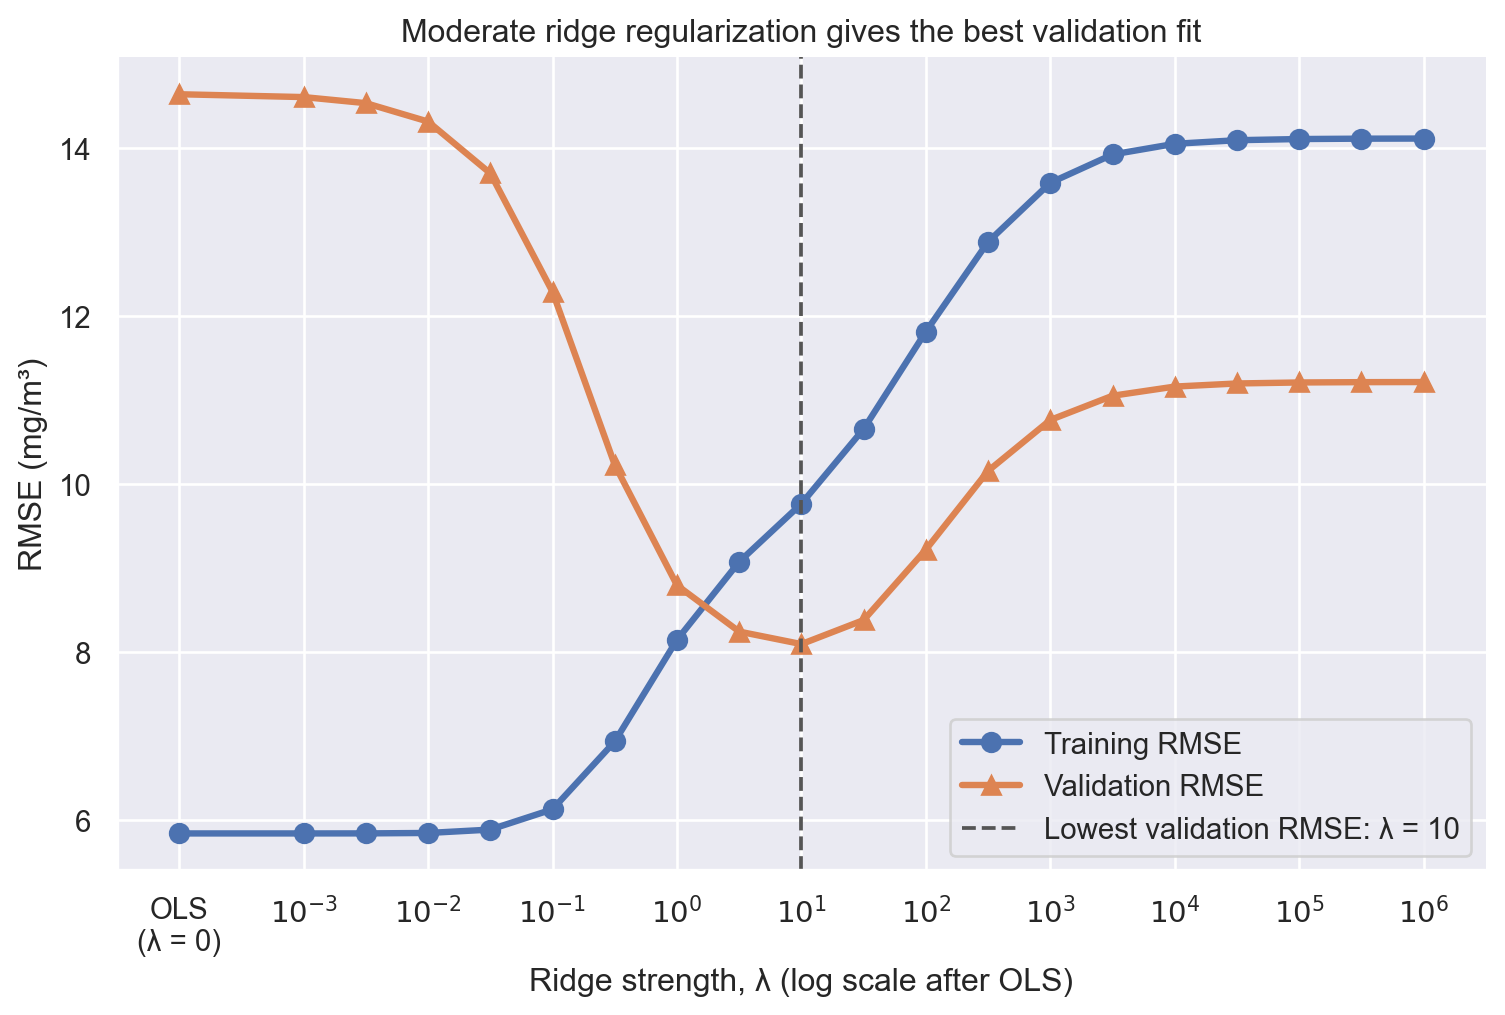

,lambda,training RMSE,validation RMSE
model,,,
OLS,0.0,5.846,14.637
Ridge (λ = 10),10.0,9.767,8.098
Ridge (λ = 1e+06),1000000.0,14.110,11.214


In [4]:
positive_ridge_results = ridge_results.loc[ridge_results["lambda"] > 0].copy()
best_row = positive_ridge_results.loc[positive_ridge_results["validation RMSE"].idxmin()]
best_ridge_lambda = float(best_row["lambda"])

# Put OLS just to the left of the log-scaled ridge strengths.
ridge_x = np.log10(positive_ridge_results["lambda"].to_numpy())
ols_x = ridge_x.min() - 1.0
plot_x = np.concatenate(([ols_x], ridge_x))

fig, axis = plt.subplots(figsize=(9.2, 5.5))
axis.plot(
    plot_x,
    ridge_results["training RMSE"].to_numpy(),
    marker="o",
    markersize=7,
    linewidth=2.4,
    color=training_color,
    label="Training RMSE",
)
axis.plot(
    plot_x,
    ridge_results["validation RMSE"].to_numpy(),
    marker="^",
    markersize=7,
    linewidth=2.4,
    color=validation_color,
    label="Validation RMSE",
)
axis.axvline(
    np.log10(best_ridge_lambda),
    color="#555555",
    linestyle="--",
    linewidth=1.4,
    label=f"Lowest validation RMSE: λ = {best_ridge_lambda:g}",
)

tick_positions = [ols_x] + list(range(-3, 7))
tick_labels = ["OLS\n(λ = 0)"] + [rf"$10^{{{power}}}$" for power in range(-3, 7)]
axis.set(
    title="Moderate ridge regularization gives the best validation fit",
    xlabel="Ridge strength, λ (log scale after OLS)",
    ylabel="RMSE (mg/m³)",
    xticks=tick_positions,
    xticklabels=tick_labels,
)
axis.legend(frameon=True)
sns.despine(ax=axis)
plt.show()

ridge_results.loc[["OLS", f"Ridge (λ = {best_ridge_lambda:g})", "Ridge (λ = 1e+06)"]].round(3)


## 5. Look inside the coefficients

Ridge does not remove features. It retains the full feature set and smoothly shrinks the standardized coefficients as $\lambda$ increases. The coefficient values below are in standardized-feature units, so their magnitudes can be compared across the original measurements.

These coefficients describe a predictive model, not a causal analysis. Several gas-turbine measurements are correlated, so a coefficient's sign or magnitude alone should not be interpreted as an isolated physical effect.

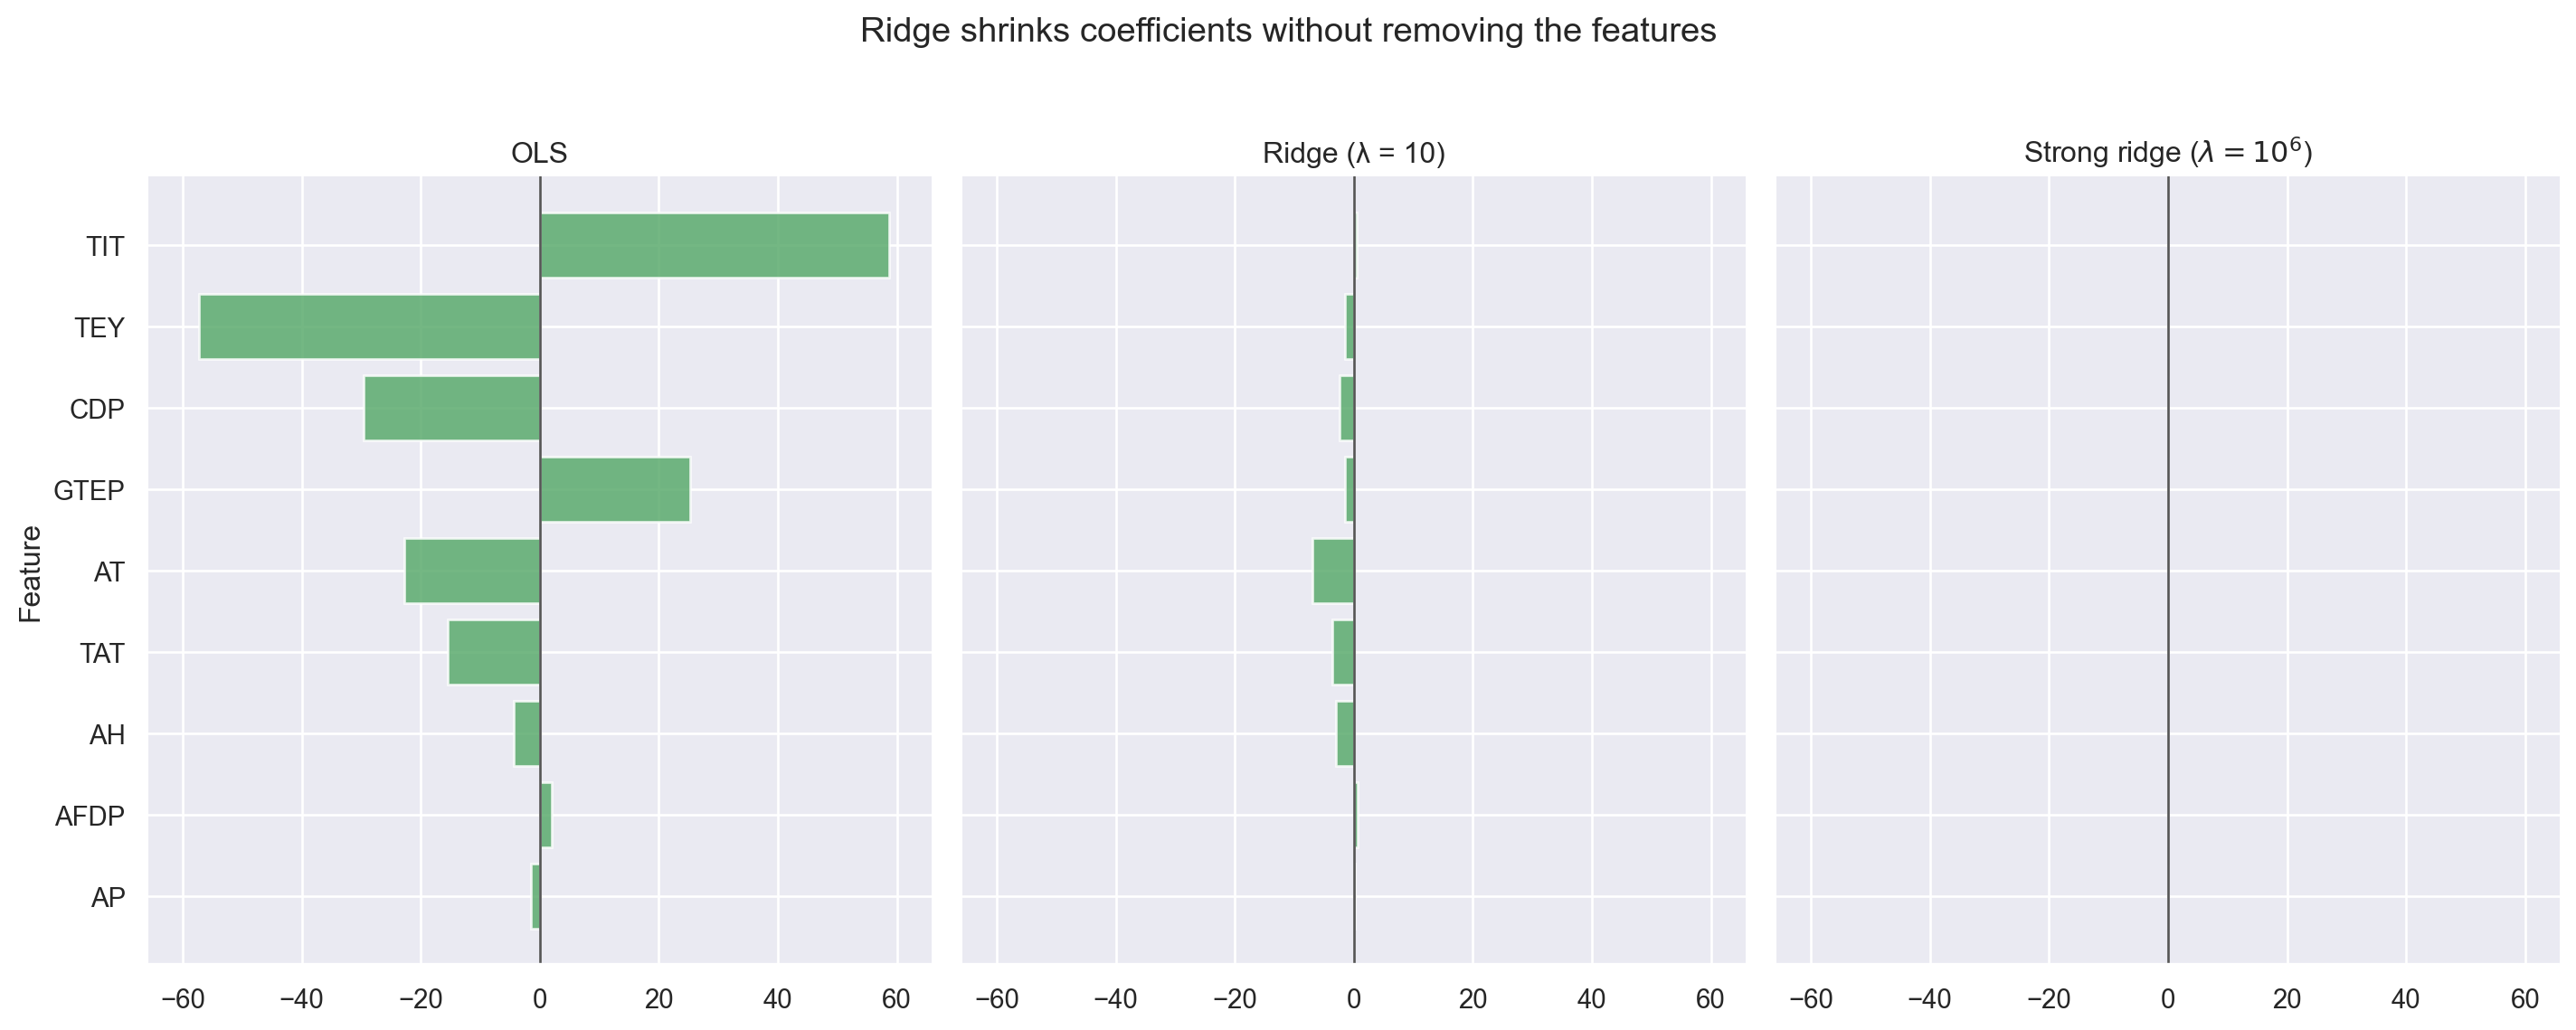

,OLS,Ridge (λ = 10),Strong ridge (λ = 1e6)
AP,-1.446,0.167,0.0
AFDP,2.055,0.641,-0.0
AH,-4.440,-3.029,0.0
TAT,-15.419,-3.604,-0.0
AT,-22.788,-7.009,-0.0
GTEP,25.206,-1.499,-0.0
CDP,-29.611,-2.405,-0.0
TEY,-57.204,-1.496,-0.0
TIT,58.717,0.465,-0.0


In [5]:
selected_models = {
    "OLS": fitted_models["OLS"],
    f"Ridge (λ = {best_ridge_lambda:g})": fitted_models[f"Ridge (λ = {best_ridge_lambda:g})"],
    "Strong ridge (λ = 1e6)": fitted_models["Ridge (λ = 1e+06)"],
}

coefficient_table = pd.DataFrame(
    {name: model[-1].coef_ for name, model in selected_models.items()},
    index=FEATURES,
)
coefficient_table = coefficient_table.loc[coefficient_table["OLS"].abs().sort_values().index]

fig, axes = plt.subplots(1, 3, figsize=(15, 5.8), sharex=True, sharey=True)
coefficient_limit = coefficient_table.abs().to_numpy().max() * 1.12

display_labels = {
    "Strong ridge (λ = 1e6)": r"Strong ridge ($\lambda = 10^6$)",
}

for axis, (name, coefficients) in zip(axes, coefficient_table.items()):
    axis.barh(coefficient_table.index, coefficients, color=ridge_color, alpha=0.82)
    axis.axvline(0, color="#555555", linewidth=1.0)
    axis.set(title=display_labels.get(name, name), xlim=(-coefficient_limit, coefficient_limit))
    sns.despine(ax=axis, left=True)

axes[0].set_ylabel("Feature")
fig.suptitle("Ridge shrinks coefficients without removing the features", y=1.02)
fig.tight_layout()
plt.show()

coefficient_table.round(3)


## 6. Lasso can also remove features

Ridge uses a squared-coefficient penalty. **Lasso** instead penalizes the absolute values of the feature coefficients:

$$
J_{\lambda}^{\mathrm{Lasso}}(\boldsymbol{\beta})
=
\frac{1}{2n_{\mathrm{train}}}
\sum_{i=1}^{n_{\mathrm{train}}}
\left(y_i - \beta_0 - \mathbf{x}_i^T\boldsymbol{\beta}\right)^2
+
\lambda\sum_{j=1}^{d}|\beta_j|.
$$

The absolute-value penalty has sharp corners at zero. As $\lambda$ grows, a fitted coefficient can land exactly at zero. Lasso is therefore one way to perform feature selection while fitting a regression model. A zeroed coefficient does **not** prove that a measurement is physically irrelevant: correlated measurements can substitute for one another.

In this notebook, we call the penalty strength $\lambda$; scikit-learn calls the matching `Lasso` argument `alpha`. Its squared-error term is normalized by $2n_{\mathrm{train}}$, unlike the `Ridge` convention used earlier. Do not compare the numerical $\lambda$ values between the two methods; choose each with validation performance.

In [6]:
def make_lasso_model(lambda_: float) -> Pipeline:
    """Create a standardized Lasso-regression pipeline.

    Args:
        lambda_: Lasso penalty strength.

    Returns:
        A pipeline that standardizes features using training statistics before fitting.
    """
    return make_pipeline(StandardScaler(), Lasso(alpha=lambda_, max_iter=100_000))


def fit_lasso_and_score(lambda_: float) -> tuple[Pipeline, dict[str, float | int | str]]:
    """Fit one Lasso model and evaluate it on the fixed data split.

    Args:
        lambda_: Lasso penalty strength.

    Returns:
        The fitted pipeline and a row of training and validation metrics.
    """
    model = make_lasso_model(lambda_)
    model.fit(training_data[FEATURES], training_data[TARGET])
    coefficients = model[-1].coef_

    row = {
        "model": f"Lasso (λ = {lambda_:g})",
        "lambda": lambda_,
        "training RMSE": root_mean_squared_error(
            training_data[TARGET], model.predict(training_data[FEATURES])
        ),
        "validation RMSE": root_mean_squared_error(
            validation_data[TARGET], model.predict(validation_data[FEATURES])
        ),
        "nonzero coefficients": int(np.count_nonzero(np.abs(coefficients) > 1e-10)),
    }
    return model, row


candidate_lasso_lambdas = np.logspace(-4, 3, 22)
lasso_models: dict[str, Pipeline] = {}
lasso_rows = []

for lambda_ in candidate_lasso_lambdas:
    model, row = fit_lasso_and_score(float(lambda_))
    lasso_models[row["model"]] = model
    lasso_rows.append(row)

lasso_results = pd.DataFrame(lasso_rows).set_index("model")
lasso_results.round(3)


,lambda,training RMSE,validation RMSE,nonzero coefficients
model,,,,
Lasso (λ = 0.0001),0.000,5.846,14.634,9
Lasso (λ = 0.000215443),0.000,5.846,14.630,9
Lasso (λ = 0.000464159),0.000,5.846,14.620,9
Lasso (λ = 0.001),0.001,5.846,14.599,9
Lasso (λ = 0.00215443),0.002,5.846,14.554,9
Lasso (λ = 0.00464159),0.005,5.847,14.455,9
Lasso (λ = 0.01),0.010,5.852,14.245,9
Lasso (λ = 0.0215443),0.022,5.875,13.797,9
Lasso (λ = 0.0464159),0.046,5.983,12.870,9


## 7. Select the Lasso strength with validation data

As with ridge, low penalty strengths leave the fit close to ordinary least squares. As the Lasso penalty increases, it first removes some coefficients and eventually removes all of them. We again select the $\lambda$ with the lowest validation RMSE.

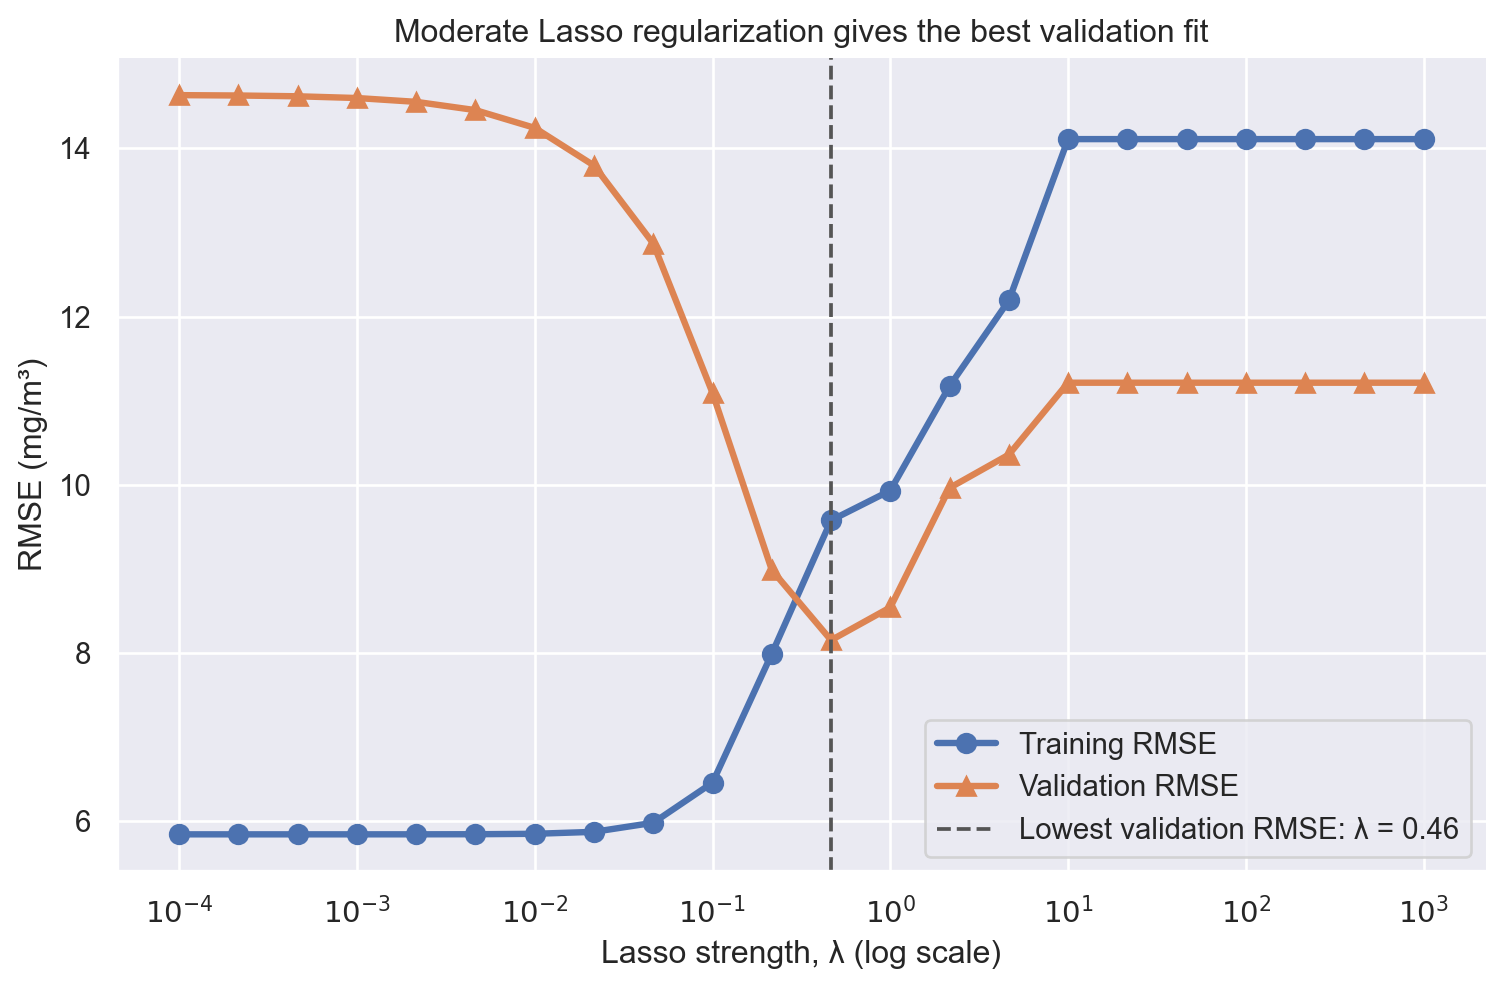

,lambda,training RMSE,validation RMSE,nonzero coefficients
model,,,,
Lasso (λ = 0.464159),0.464,9.579,8.154,5
Lasso (λ = 10),10.000,14.111,11.215,0


In [7]:
best_lasso_row = lasso_results.loc[lasso_results["validation RMSE"].idxmin()]
best_lasso_lambda = float(best_lasso_row["lambda"])
lasso_x = np.log10(lasso_results["lambda"].to_numpy())

fig, axis = plt.subplots(figsize=(9.2, 5.5))
axis.plot(
    lasso_x,
    lasso_results["training RMSE"].to_numpy(),
    marker="o",
    markersize=7,
    linewidth=2.4,
    color=training_color,
    label="Training RMSE",
)
axis.plot(
    lasso_x,
    lasso_results["validation RMSE"].to_numpy(),
    marker="^",
    markersize=7,
    linewidth=2.4,
    color=validation_color,
    label="Validation RMSE",
)
axis.axvline(
    np.log10(best_lasso_lambda),
    color="#555555",
    linestyle="--",
    linewidth=1.4,
    label=f"Lowest validation RMSE: λ = {best_lasso_lambda:.2g}",
)
axis.set(
    title="Moderate Lasso regularization gives the best validation fit",
    xlabel="Lasso strength, λ (log scale)",
    ylabel="RMSE (mg/m³)",
    xticks=list(range(-4, 4)),
    xticklabels=[rf"$10^{{{power}}}$" for power in range(-4, 4)],
)
axis.legend(frameon=True)
sns.despine(ax=axis)
plt.show()

lasso_results.loc[
    [
        f"Lasso (λ = {best_lasso_lambda:g})",
        "Lasso (λ = 10)",
    ]
].round(3)


## 8. See which coefficients Lasso removes

At the selected Lasso strength, some coefficients are exactly zero. The chart uses standardized-feature units. Gray feature labels mark measurements whose fitted coefficients are zero. This is different from ridge, which keeps every coefficient nonzero while shrinking it.

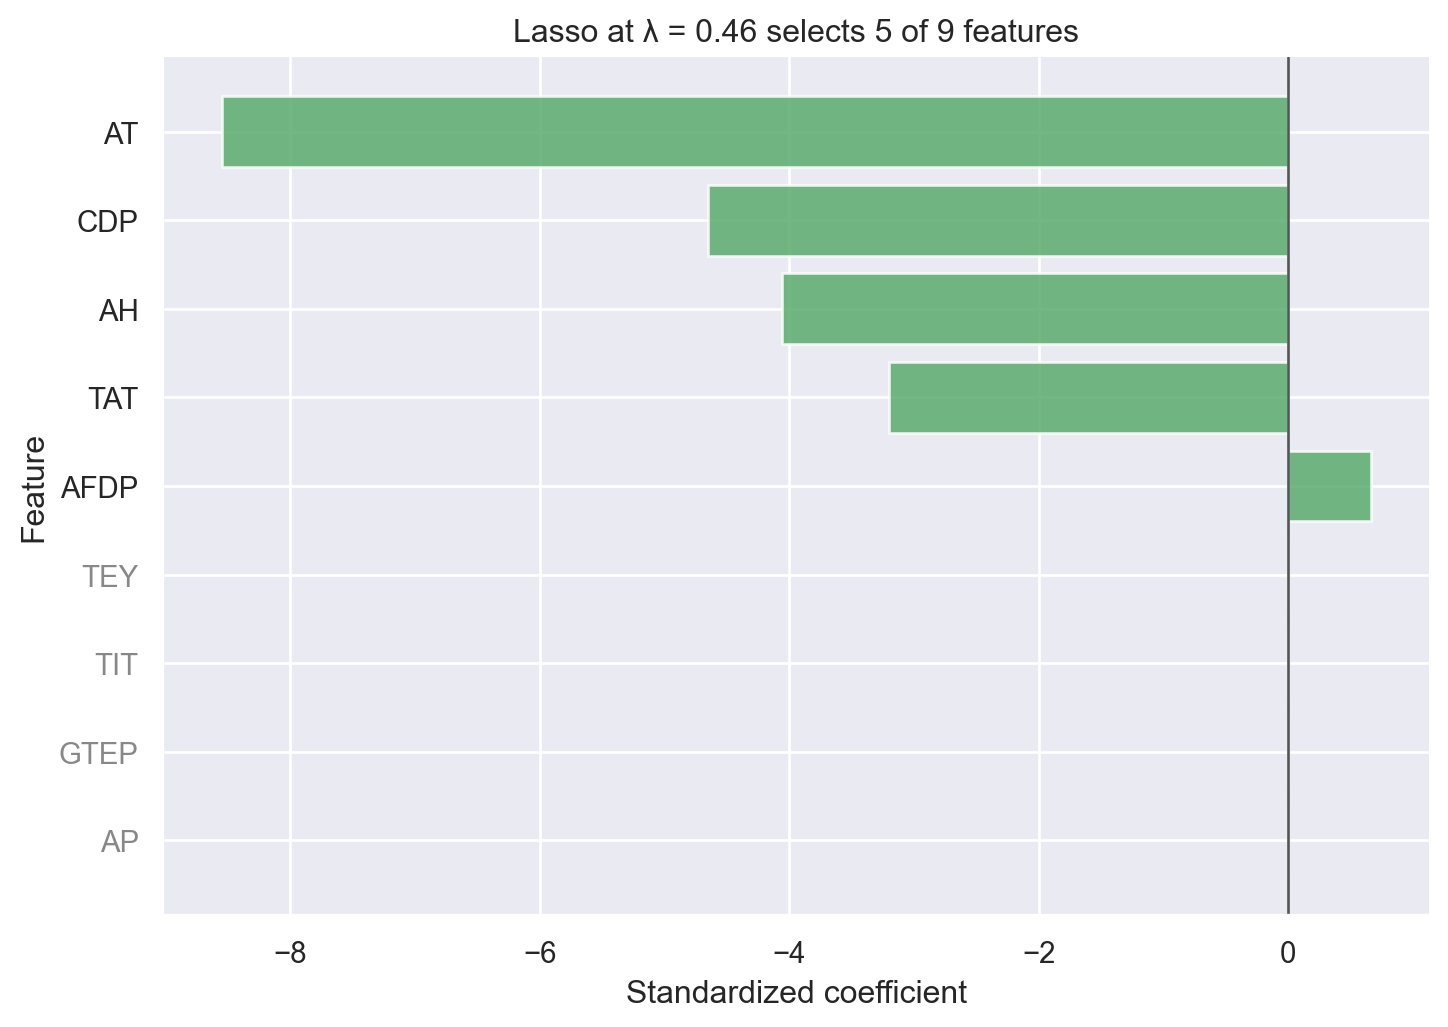

,Lasso coefficient,selected by Lasso
AP,-0.000,False
GTEP,-0.000,False
TIT,0.000,False
TEY,-0.000,False
AFDP,0.669,True
TAT,-3.203,True
AH,-4.058,True
CDP,-4.654,True
AT,-8.552,True


In [8]:
best_lasso_model = lasso_models[f"Lasso (λ = {best_lasso_lambda:g})"]
lasso_coefficients = pd.Series(best_lasso_model[-1].coef_, index=FEATURES)
lasso_coefficients = lasso_coefficients.loc[lasso_coefficients.abs().sort_values().index]
is_selected = lasso_coefficients.abs() > 1e-10
bar_colors = [ridge_color if selected else "#b0b0b0" for selected in is_selected]

fig, axis = plt.subplots(figsize=(8.5, 5.8))
axis.barh(lasso_coefficients.index, lasso_coefficients, color=bar_colors, alpha=0.82)
axis.axvline(0, color="#555555", linewidth=1.0)
axis.set(
    title=f"Lasso at λ = {best_lasso_lambda:.2g} selects {is_selected.sum()} of {len(FEATURES)} features",
    xlabel="Standardized coefficient",
    ylabel="Feature",
)
for label, selected in zip(axis.get_yticklabels(), is_selected):
    if not selected:
        label.set_color("#888888")
sns.despine(ax=axis, left=True)
plt.show()

lasso_coefficient_table = pd.DataFrame(
    {
        "Lasso coefficient": lasso_coefficients,
        "selected by Lasso": is_selected,
    }
)
lasso_coefficient_table.round(3)


## 9. What did regularization buy us?

The ordinary least-squares model achieves the lowest training RMSE because it has no constraint on its coefficients. It generalizes poorly on this limited calibration sample. Moderate Ridge and Lasso regularization accept a worse training fit in exchange for substantially better validation fit. Very strong regularization underfits.

## Takeaways

- Ridge retains all plausible measured features and smoothly shrinks their coefficients.
- Lasso can shrink coefficients exactly to zero, yielding one data-driven feature-selection rule.
- Feature standardization makes both penalties fair across variables with different units.
- The regularization strength $\lambda$ is a **hyperparameter**: select it using validation performance. Its numerical scale differs between Ridge and Lasso.
- One validation split is a teaching example; its exact best $\lambda$ and selected Lasso features can change with a different split.

## Try it

Fit one additional Ridge or Lasso strength and compare its training and validation RMSE with the tables above.

[← Return to Evaluation](index.qmd)

In [9]:
# Try another Ridge strength.
# my_ridge_lambda = 30.0
# my_ridge_model, my_ridge_result = fit_ridge_and_score(my_ridge_lambda)
# pd.DataFrame([my_ridge_result]).set_index("model").round(3)

# Try another Lasso strength.
# my_lasso_lambda = 1.0
# my_lasso_model, my_lasso_result = fit_lasso_and_score(my_lasso_lambda)
# pd.DataFrame([my_lasso_result]).set_index("model").round(3)
